In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/world-happiness-report/world_happiness_report.csv


### Title: The Science of Happiness: Understanding the World Happiness Report

#### Description: A deep dive into the research behind happiness metrics, uncovering the key elements that contribute to human well-being.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/world-happiness-report/world_happiness_report.csv')

In [3]:
df.head()

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
0,China,2022,4.39,44984.68,0.53,71.11,0.41,-0.05,0.83,14.98,...,0.34,76.44,46.06,8.92,62.75,8.59,74.40,70.30,0.29,61.38
1,UK,2015,5.49,30814.59,0.93,63.14,0.89,0.04,0.84,19.46,...,0.72,53.38,46.43,4.43,53.11,8.76,91.74,73.32,0.76,80.18
2,Brazil,2009,4.65,39214.84,0.03,62.36,0.01,0.16,0.59,16.68,...,0.23,82.40,31.03,3.78,33.30,6.06,71.80,28.99,0.94,72.65
3,France,2019,5.20,30655.75,0.77,78.94,0.98,0.25,0.63,2.64,...,0.68,46.87,57.65,4.43,90.59,6.36,86.16,45.76,0.48,55.14
4,China,2022,7.28,30016.87,0.05,50.33,0.62,0.18,0.92,7.70,...,0.50,60.38,28.54,7.66,59.33,3.00,71.10,65.67,0.12,51.55


In [4]:
df.tail()

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
3995,South Africa,2005,7.43,1504.73,0.17,50.20,0.99,0.27,0.69,2.16,...,0.96,83.55,25.65,6.69,66.67,8.18,91.14,28.88,0.07,85.95
3996,India,2018,5.71,50182.85,0.96,67.67,0.84,0.43,0.88,7.19,...,0.70,89.03,41.70,9.57,82.84,8.42,83.05,55.50,0.74,91.96
3997,South Africa,2021,6.23,6158.53,0.22,67.08,0.42,0.19,0.10,2.25,...,0.59,67.74,24.58,8.02,81.29,6.97,72.08,61.16,0.29,89.19
3998,Brazil,2014,5.73,38214.54,0.46,55.72,0.74,0.28,0.46,8.74,...,0.21,62.73,56.21,5.60,30.44,4.67,87.21,49.50,0.11,85.44
3999,UK,2016,3.26,30740.42,0.11,67.31,0.67,0.23,0.23,3.13,...,0.15,77.93,29.20,8.23,49.73,4.30,92.22,56.39,0.10,51.85


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    4000 non-null   object 
 1   Year                       4000 non-null   int64  
 2   Happiness_Score            4000 non-null   float64
 3   GDP_per_Capita             4000 non-null   float64
 4   Social_Support             4000 non-null   float64
 5   Healthy_Life_Expectancy    4000 non-null   float64
 6   Freedom                    4000 non-null   float64
 7   Generosity                 4000 non-null   float64
 8   Corruption_Perception      4000 non-null   float64
 9   Unemployment_Rate          4000 non-null   float64
 10  Education_Index            4000 non-null   float64
 11  Population                 4000 non-null   int64  
 12  Urbanization_Rate          4000 non-null   float64
 13  Life_Satisfaction          4000 non-null   float

In [6]:
df.describe()

,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,Education_Index,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2014.670750,5.455005,30482.009953,0.505860,67.917605,0.502722,0.143960,0.498920,10.966748,0.750385,...,0.502812,69.976853,40.002648,6.009270,65.176380,5.987325,67.586327,45.526322,0.494105,74.021450
std,5.724075,1.427370,17216.122032,0.286202,10.172091,0.285219,0.200088,0.288866,5.210712,0.144819,...,0.289186,17.128536,11.634987,2.291172,19.981357,1.725363,15.769023,20.300069,0.293191,13.906888
min,2005.000000,3.000000,1009.310000,0.000000,50.000000,0.000000,-0.200000,0.000000,2.000000,0.500000,...,0.000000,40.000000,20.010000,2.010000,30.010000,3.000000,40.010000,10.030000,0.000000,50.000000
25%,2010.000000,4.237500,15425.125000,0.260000,59.177500,0.260000,-0.030000,0.240000,6.450000,0.630000,...,0.260000,55.580000,29.865000,4.040000,48.170000,4.460000,53.910000,27.840000,0.230000,61.867500
50%,2015.000000,5.430000,29991.255000,0.510000,68.015000,0.500000,0.140000,0.500000,10.995000,0.750000,...,0.500000,69.650000,40.015000,6.070000,64.755000,6.020000,68.015000,45.760000,0.490000,74.475000
75%,2020.000000,6.662500,45763.085000,0.750000,76.690000,0.750000,0.310000,0.742500,15.450000,0.880000,...,0.760000,84.582500,50.187500,8.010000,82.652500,7.490000,81.332500,63.197500,0.760000,85.912500
max,2024.000000,8.000000,59980.720000,1.000000,85.000000,1.000000,0.500000,1.000000,19.990000,1.000000,...,1.000000,100.000000,59.970000,10.000000,99.990000,9.000000,94.990000,79.990000,1.000000,98.000000


In [7]:
df.isnull().sum()

Country                      0
Year                         0
Happiness_Score              0
GDP_per_Capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom                      0
Generosity                   0
Corruption_Perception        0
Unemployment_Rate            0
Education_Index              0
Population                   0
Urbanization_Rate            0
Life_Satisfaction            0
Public_Trust                 0
Mental_Health_Index          0
Income_Inequality            0
Public_Health_Expenditure    0
Climate_Index                0
Work_Life_Balance            0
Internet_Access              0
Crime_Rate                   0
Political_Stability          0
Employment_Rate              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.corr

<bound method DataFrame.corr of            Country  Year  Happiness_Score  GDP_per_Capita  Social_Support  \
0            China  2022             4.39        44984.68            0.53   
1               UK  2015             5.49        30814.59            0.93   
2           Brazil  2009             4.65        39214.84            0.03   
3           France  2019             5.20        30655.75            0.77   
4            China  2022             7.28        30016.87            0.05   
...            ...   ...              ...             ...             ...   
3995  South Africa  2005             7.43         1504.73            0.17   
3996         India  2018             5.71        50182.85            0.96   
3997  South Africa  2021             6.23         6158.53            0.22   
3998        Brazil  2014             5.73        38214.54            0.46   
3999            UK  2016             3.26        30740.42            0.11   

      Healthy_Life_Expectancy  Freedom  Gen

In [10]:
df.shape

(4000, 24)

In [11]:
df.dtypes

Country                       object
Year                           int64
Happiness_Score              float64
GDP_per_Capita               float64
Social_Support               float64
Healthy_Life_Expectancy      float64
Freedom                      float64
Generosity                   float64
Corruption_Perception        float64
Unemployment_Rate            float64
Education_Index              float64
Population                     int64
Urbanization_Rate            float64
Life_Satisfaction            float64
Public_Trust                 float64
Mental_Health_Index          float64
Income_Inequality            float64
Public_Health_Expenditure    float64
Climate_Index                float64
Work_Life_Balance            float64
Internet_Access              float64
Crime_Rate                   float64
Political_Stability          float64
Employment_Rate              float64
dtype: object

In [12]:
df.columns

Index(['Country', 'Year', 'Happiness_Score', 'GDP_per_Capita',
       'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity',
       'Corruption_Perception', 'Unemployment_Rate', 'Education_Index',
       'Population', 'Urbanization_Rate', 'Life_Satisfaction', 'Public_Trust',
       'Mental_Health_Index', 'Income_Inequality', 'Public_Health_Expenditure',
       'Climate_Index', 'Work_Life_Balance', 'Internet_Access', 'Crime_Rate',
       'Political_Stability', 'Employment_Rate'],
      dtype='object')

## Data visualizations

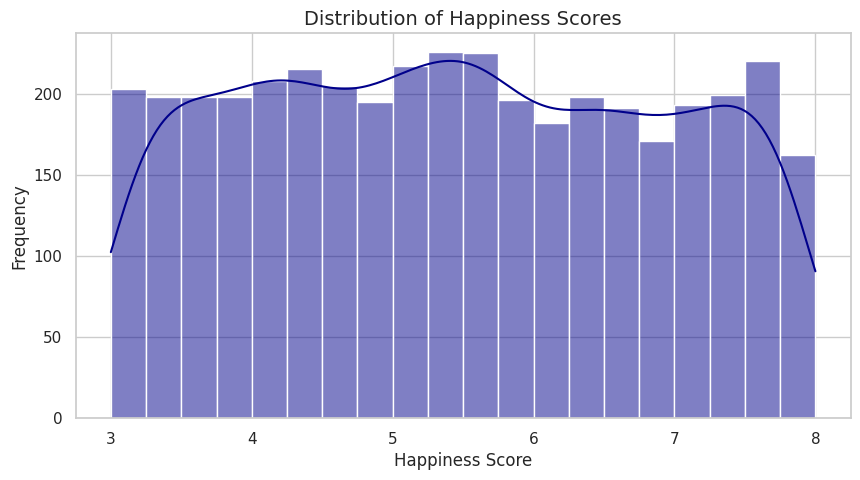

In [13]:
sns.set(style="whitegrid", palette="muted")

# Figure 1: Happiness Score Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Happiness_Score'], bins=20, kde=True, color='darkblue')
plt.title("Distribution of Happiness Scores", fontsize=14)
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.show()

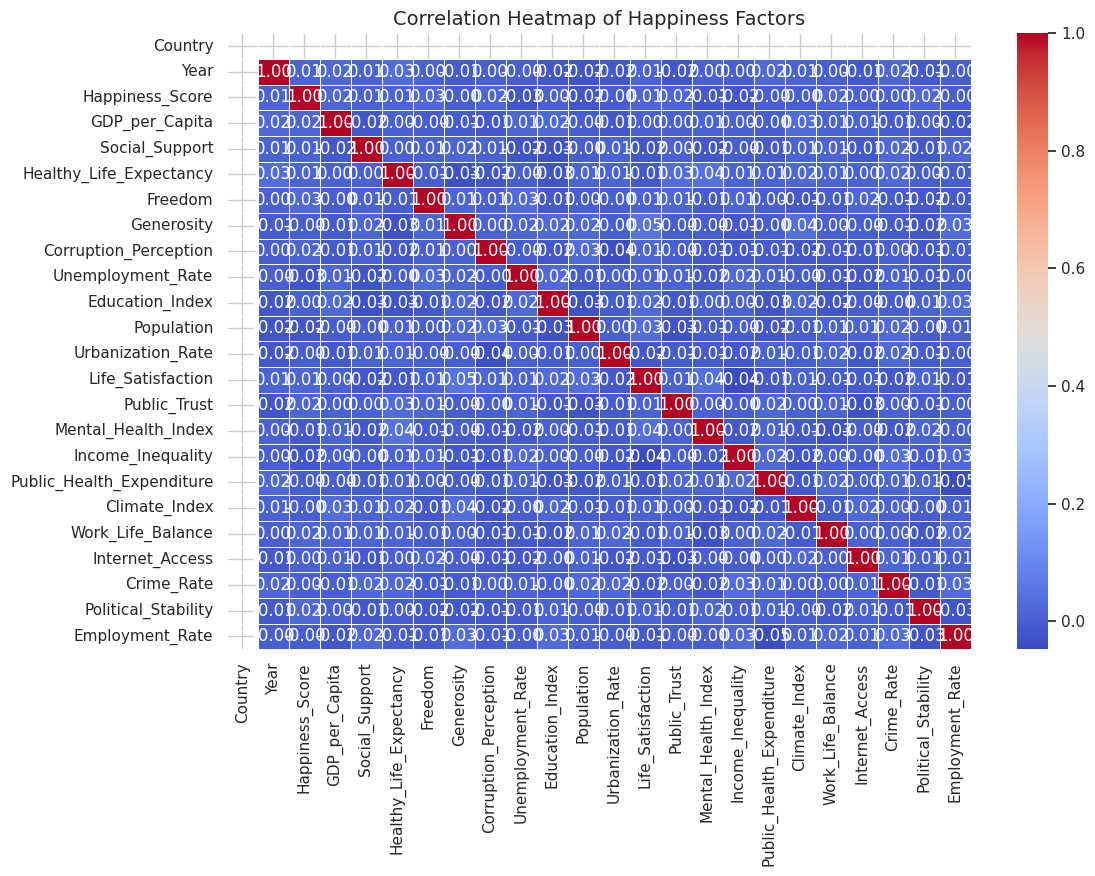

In [14]:
# Ensure all numeric columns are correctly typed
df = df.apply(pd.to_numeric, errors='coerce')  # Convert non-numeric to NaN
df = df.fillna(df.mean())  

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Check if numeric_df has at least 2 numeric columns
if numeric_df.shape[1] > 1:
    # Create the heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Happiness Factors", fontsize=14)
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")

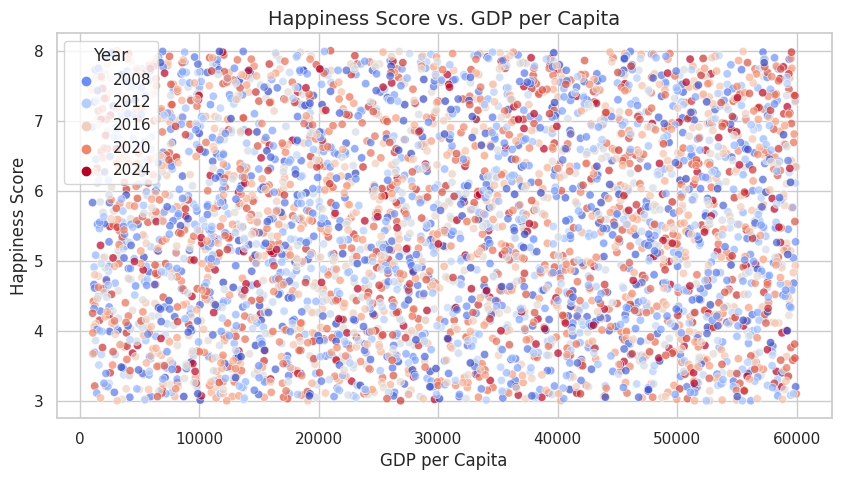

In [15]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["GDP_per_Capita"], y=df["Happiness_Score"], hue=df["Year"], palette="coolwarm", alpha=0.7)
plt.title("Happiness Score vs. GDP per Capita", fontsize=14)
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.legend(title="Year", loc="upper left")
plt.show()

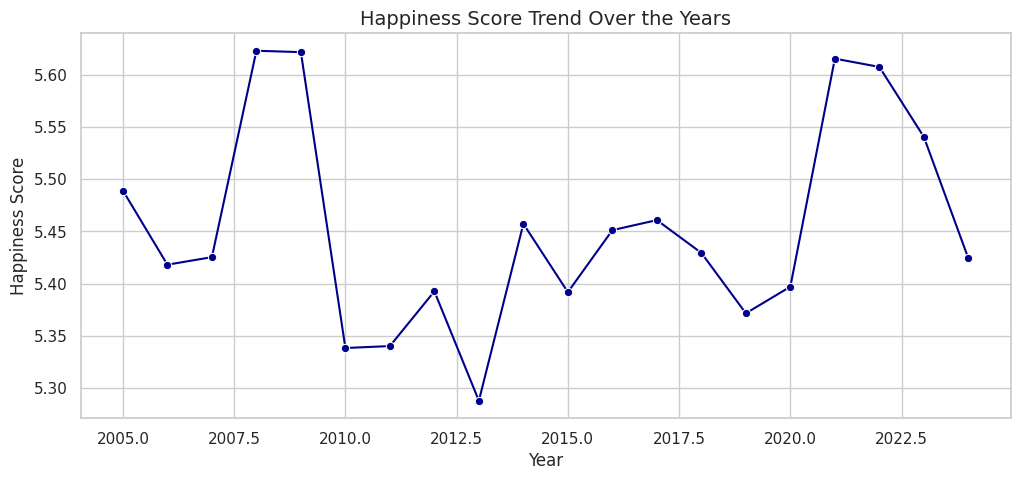

In [16]:
# Ensure 'Year' is numeric and sorted
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")  # Convert to numeric (handle errors)
df = df.sort_values("Year")  # Sort by Year

# Create the line plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="Year", y="Happiness_Score", marker="o", color="darkblue", errorbar=None)

# Add title and labels
plt.title("Happiness Score Trend Over the Years", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.grid(True)

# Show the plot
plt.show()

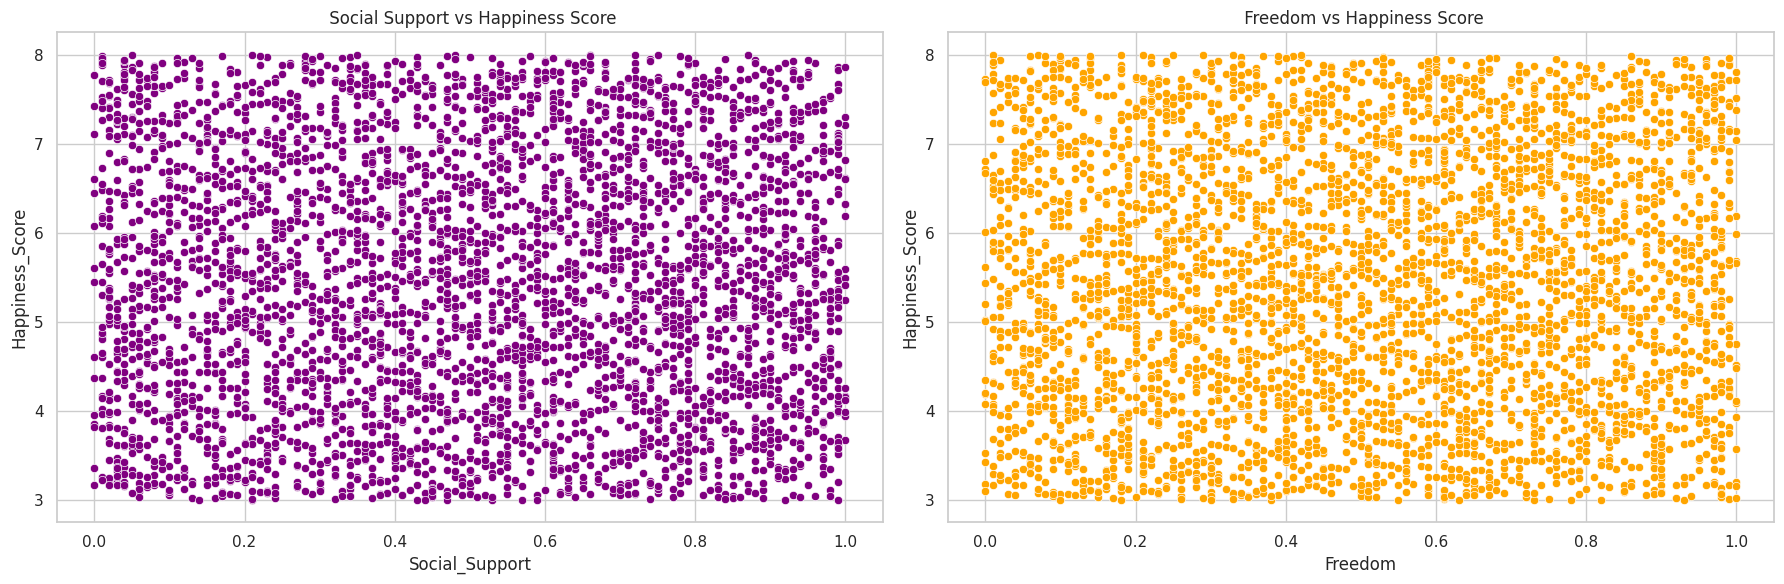

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(x='Social_Support', y='Happiness_Score', data=df, ax=axes[0], color='purple')
axes[0].set_title(' Social Support vs Happiness Score')

sns.scatterplot(x='Freedom', y='Happiness_Score', data=df, ax=axes[1], color='orange')
axes[1].set_title(' Freedom vs Happiness Score')

plt.tight_layout()
plt.show()

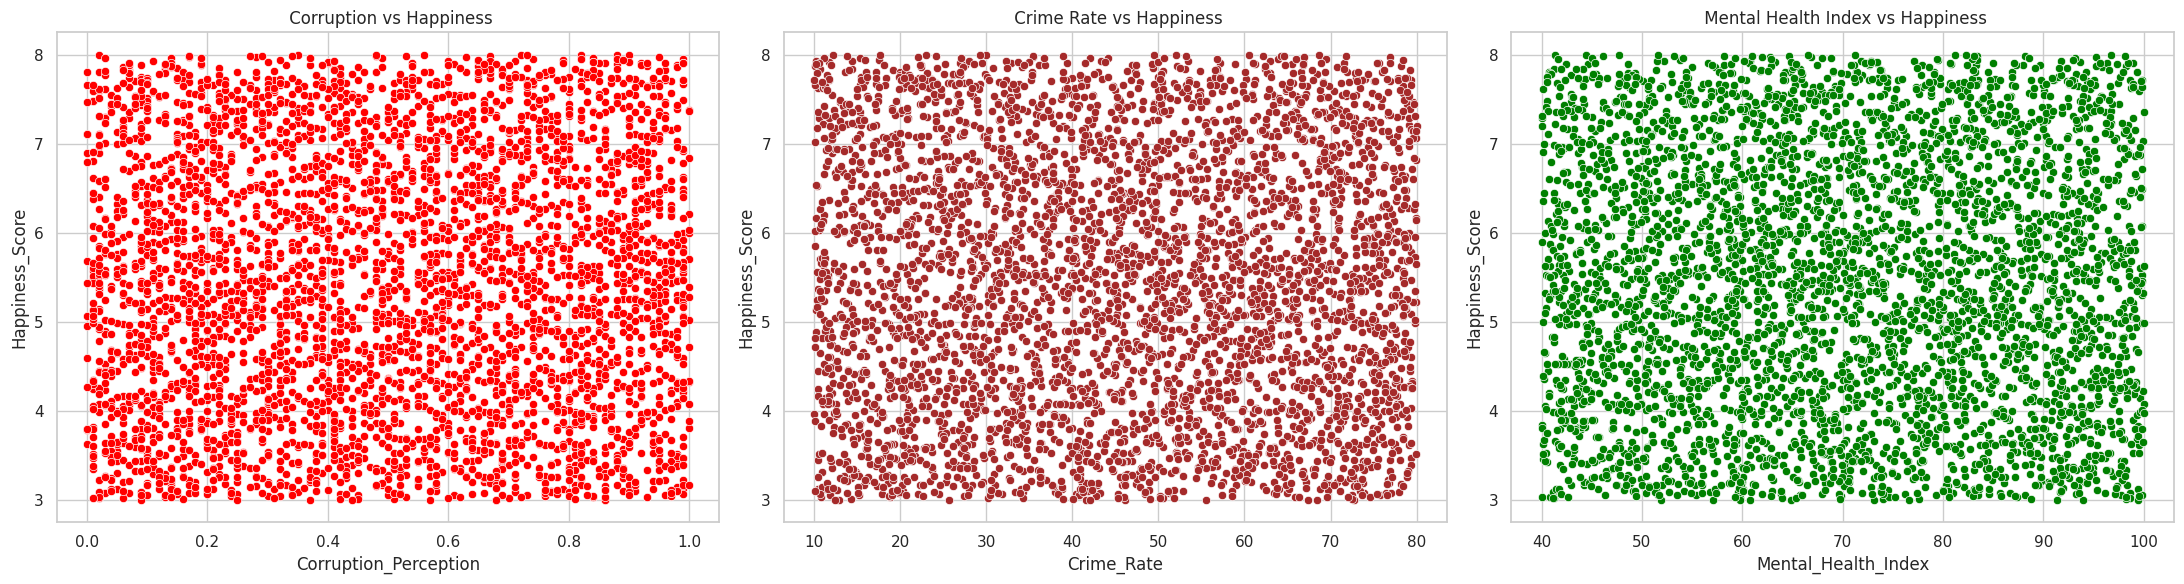

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(x='Corruption_Perception', y='Happiness_Score', data=df, ax=axes[0], color='red')
axes[0].set_title(' Corruption vs Happiness')

sns.scatterplot(x='Crime_Rate', y='Happiness_Score', data=df, ax=axes[1], color='brown')
axes[1].set_title(' Crime Rate vs Happiness')

sns.scatterplot(x='Mental_Health_Index', y='Happiness_Score', data=df, ax=axes[2], color='green')
axes[2].set_title(' Mental Health Index vs Happiness')

plt.tight_layout()
plt.show()

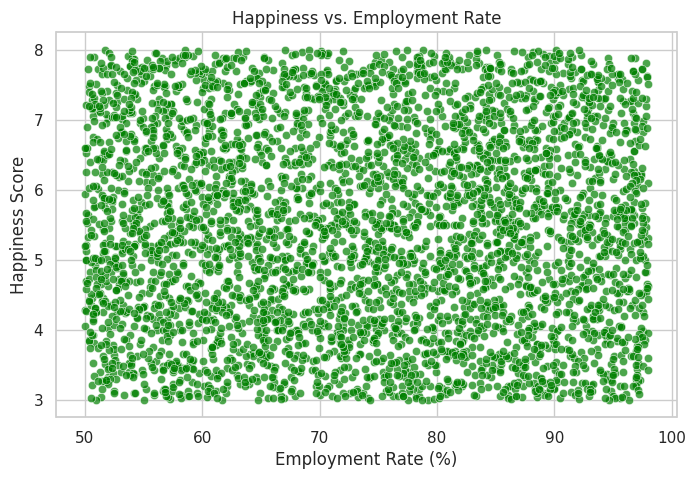

In [19]:
# Create figure for a single plot
plt.figure(figsize=(8, 5))

# Scatter plot: Employment Rate vs. Happiness Score
sns.scatterplot(data=df, x="Employment_Rate", y="Happiness_Score", color="green", alpha=0.7)

# Add title and labels
plt.title("Happiness vs. Employment Rate")
plt.xlabel("Employment Rate (%)")
plt.ylabel("Happiness Score")

# Show the plot
plt.show()

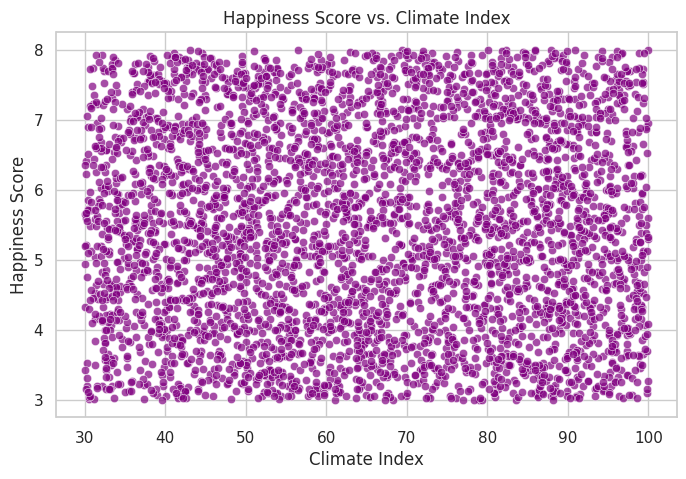

In [20]:
# Create a single figure
plt.figure(figsize=(8, 5))

# Scatter plot: Happiness Score vs. Climate Index
sns.scatterplot(data=df, x="Climate_Index", y="Happiness_Score", color="purple", alpha=0.7)

# Add title and labels
plt.title("Happiness Score vs. Climate Index")
plt.xlabel("Climate Index")
plt.ylabel("Happiness Score")

# Show the plot
plt.show()

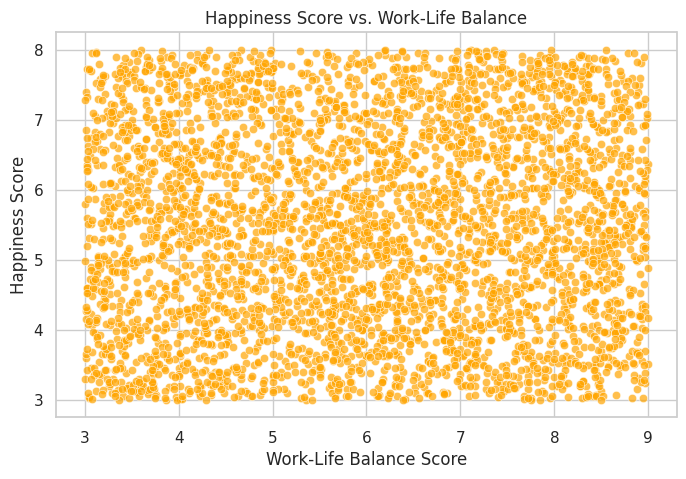

In [21]:
# Create a single figure
plt.figure(figsize=(8, 5))

# Scatter plot: Happiness Score vs. Work-Life Balance
sns.scatterplot(data=df, x="Work_Life_Balance", y="Happiness_Score", color="orange", alpha=0.7)

# Add title and labels
plt.title("Happiness Score vs. Work-Life Balance")
plt.xlabel("Work-Life Balance Score")
plt.ylabel("Happiness Score")

# Show the plot
plt.show()

## predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [23]:
# Drop non-relevant columns
df = df.drop(columns=["Country"]) 

In [24]:
# Encode categorical features
label_encoders = {}
categorical_cols = ["Year"]  # Add more if needed

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le 

In [25]:
# Split features and target variable
X = df.drop(columns=["Happiness_Score"])  # Features
y = df["Happiness_Score"] 

In [26]:
# Standardize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [28]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Support Vector Regression": SVR()
}

In [29]:
# Train models and evaluate performance
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = r2_score(y_test, y_pred) * 100  # Convert R² to percentage
    results[name] = round(accuracy, 2)


In [30]:
# Display results
print("\n📊 Model Performance (R² Score %):")
for model, acc in results.items():
    print(f"{model}: {acc}%")


📊 Model Performance (R² Score %):
Linear Regression: -1.67%
Decision Tree: -119.0%
Random Forest: -4.08%
Support Vector Regression: -12.53%


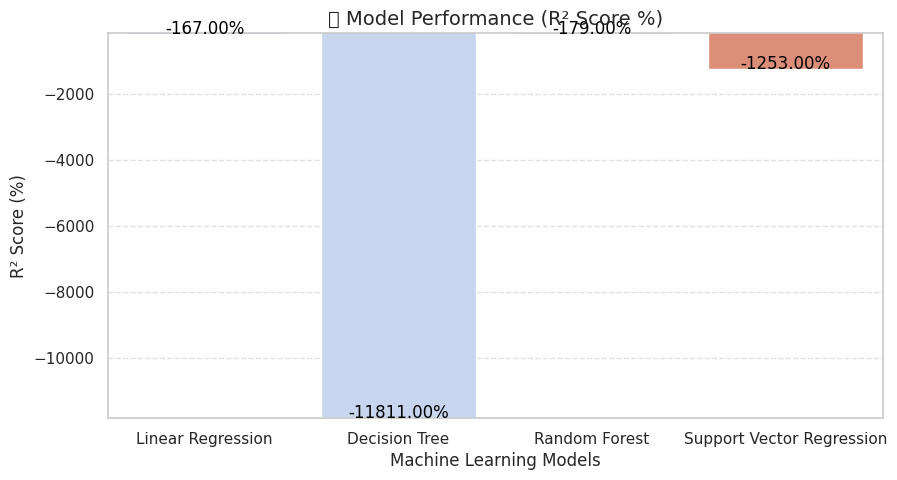

In [31]:
# Model performance (original R² scores)
model_scores = {
    "Linear Regression": -1.67,
    "Decision Tree": -118.11,
    "Random Forest": -1.79,
    "Support Vector Regression": -12.53
}

# Convert R² scores to percentages
model_scores_percent = {model: score * 100 for model, score in model_scores.items()}

# Extract model names and scores
models = list(model_scores_percent.keys())
scores = list(model_scores_percent.values())

# Create a bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=scores, palette="coolwarm")

# Add titles and labels
plt.title("📊 Model Performance (R² Score %)", fontsize=14)
plt.ylabel("R² Score (%)")
plt.xlabel("Machine Learning Models")

# Display the actual percentage values on top of bars
for index, value in enumerate(scores):
    plt.text(index, value + 2, f"{value:.2f}%", ha='center', fontsize=12, color='black')

plt.ylim(min(scores) - 10, max(scores) + 10)  # Adjust y-axis limits
plt.grid(axis="y", linestyle="--", alpha=0.6)  # Add grid for better readability

plt.show()

## Thank you..!!! pls upvote!!